# Importar Bibliotecas Requeridas
Importa las bibliotecas necesarias como NumPy, Pandas y scikit-learn para el manejo de datos y el entrenamiento del modelo.

In [1]:
# Importar Bibliotecas Requeridas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib

# Verificar Valores Faltantes
Verifica si hay valores NaN en el conjunto de datos antes del preprocesamiento.

In [2]:
# Verificar Valores Faltantes
df_check = pd.read_csv('../DARA_PROC/combined_features.csv')
print("Total NaN values in dataset:", df_check.isna().sum().sum())
print("NaN values per column:")
print(df_check.isna().sum())
print("\nTotal zero values in features:", (df_check[['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']] == 0).sum().sum())

Total NaN values in dataset: 0
NaN values per column:
UNIX Timestamp       0
DateTime             0
ECG_mean             0
ECG_std              0
ECG_range            0
ECG_energy           0
ECG_samp_ent         0
ECG_missing_peaks    0
SDNN                 0
RMSSD                0
pNN50                0
HR_mean              0
HR_max               0
HR_min               0
FatigueIndex         0
dtype: int64

Total zero values in features: 7404


# Cargar y Preparar Datos
Carga el conjunto de datos desde combined_features.csv y realiza preprocesamiento como manejar valores faltantes y escalado de características.

In [3]:
# Cargar y Preparar Datos
df = pd.read_csv('../DARA_PROC/combined_features.csv')

# Select features and target
features = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
target = 'FatigueIndex'

X = df[features]
y = df[target]

# Handle missing values (if any)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# No feature scaling needed for tree-based models like XGBoost
X_scaled = X

# Dividir Datos en Conjuntos de Entrenamiento, Validación y Prueba
Usa train_test_split para crear conjuntos de entrenamiento (60%), validación (20%) y prueba (20%).

In [4]:
# Dividir Datos en Conjuntos de Entrenamiento, Validación y Prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 60% train, 20% val, 20% test

# Elegir e Inicializar un Modelo
Selecciona un algoritmo de aprendizaje automático (ej. XGBoost) e inicializa el modelo con parámetros predeterminados o personalizados.

In [5]:
# Elegir e Inicializar un Modelo
model = XGBRegressor(n_estimators=100, early_stopping_rounds=10, eval_metric='rmse', random_state=42)

# Entrenar el Modelo
Ajusta el modelo a los datos de entrenamiento usando el método fit().

In [6]:
# Entrenar el Modelo
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)
print(f"Número de árboles usados: {model.best_iteration + 1}")

[0]	validation_0-rmse:1.73311
[1]	validation_0-rmse:1.20025
[2]	validation_0-rmse:0.83531
[3]	validation_0-rmse:0.59846
[4]	validation_0-rmse:0.45804
[5]	validation_0-rmse:0.36111
[6]	validation_0-rmse:0.30698
[7]	validation_0-rmse:0.27794
[8]	validation_0-rmse:0.25853
[9]	validation_0-rmse:0.24965
[10]	validation_0-rmse:0.24398
[11]	validation_0-rmse:0.24220
[12]	validation_0-rmse:0.24007
[13]	validation_0-rmse:0.24071
[14]	validation_0-rmse:0.24066
[15]	validation_0-rmse:0.24013
[16]	validation_0-rmse:0.23874
[17]	validation_0-rmse:0.23701
[18]	validation_0-rmse:0.23626
[19]	validation_0-rmse:0.23664
[20]	validation_0-rmse:0.23563
[21]	validation_0-rmse:0.23421
[22]	validation_0-rmse:0.23376
[23]	validation_0-rmse:0.23356
[24]	validation_0-rmse:0.23223
[25]	validation_0-rmse:0.23107
[26]	validation_0-rmse:0.23057
[27]	validation_0-rmse:0.23084
[28]	validation_0-rmse:0.23097
[29]	validation_0-rmse:0.23088
[30]	validation_0-rmse:0.23076
[31]	validation_0-rmse:0.23074
[32]	validation_0-

In [7]:
# Guardar el Modelo XGBoost de Regresión
joblib.dump(model, 'xgboost_regression_model.pkl')
print("Modelo XGBoost de regresión guardado como 'xgboost_regression_model.pkl'")

Modelo XGBoost de regresión guardado como 'xgboost_regression_model.pkl'


<Figure size 2000x1000 with 0 Axes>

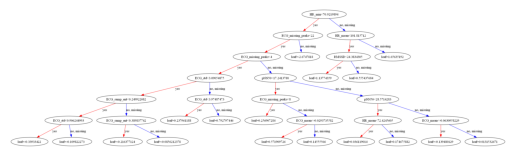

In [8]:
# Visualizar el Árbol 1 del Modelo XGBoost
# Para mejor visibilidad, aumentamos el tamaño y guardamos en alta resolución
import os
os.environ['PATH'] += r";C:\Program Files\Graphviz\bin"
plt.figure(figsize=(20, 10))
xgb.plot_tree(model, tree_idx=1)
plt.savefig('tree.png', dpi=300, bbox_inches='tight')
plt.show()

# Evaluar el Rendimiento del Modelo
Evalúa el modelo usando métricas como el error cuadrático medio o R-cuadrado en el conjunto de prueba.

In [9]:
# Evaluar el Rendimiento del Modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error: {mse}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error: {rmse}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error: {mae}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared: {r2}')

Mean Squared Error: 0.07565211414355003
Root Mean Squared Error: 0.27504929402481665
Mean Absolute Error: 0.10756748987743568
R-squared: 0.9914308327245115


# Hacer Predicciones
Usa el modelo entrenado para hacer predicciones en datos nuevos o de prueba con el método predict().

In [10]:
# Hacer Predicciones
# Ejemplo: Predecir en datos de prueba
predictions = model.predict(X_test)
print("Predicciones primeras 5:", predictions[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5:", predictions[:5] - y_test.iloc[:5].values)

Predicciones primeras 5: [-5.4182034 -4.982992  -5.25307   -4.730266  -4.9872613]
Valores reales primeras 5: [-5.40354776 -4.99209565 -5.26389479 -4.723989   -4.97734157]
Errores (Pred - Real) primeras 5: [-0.0146556   0.00910348  0.01082491 -0.0062771  -0.00991973]


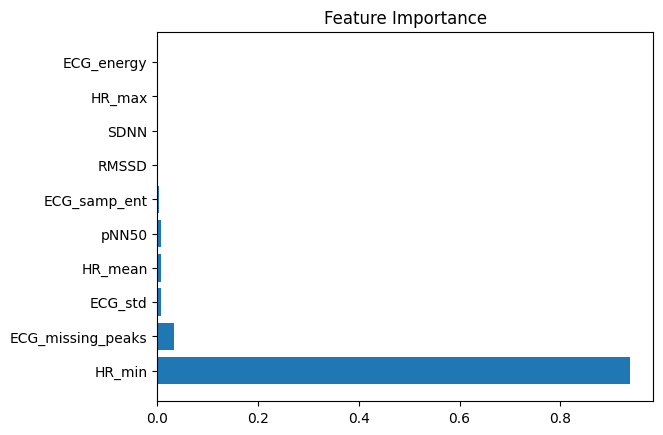

ECG_mean: 0.0002
ECG_std: 0.0077
ECG_range: 0.0002
ECG_energy: 0.0003
ECG_samp_ent: 0.0025
ECG_missing_peaks: 0.0332
SDNN: 0.0011
RMSSD: 0.0013
pNN50: 0.0070
HR_mean: 0.0077
HR_max: 0.0008
HR_min: 0.9380


In [11]:
# Importancia de Características (Modelo Original)
# Mostrar la importancia de cada característica en el modelo XGBoost
importances = model.feature_importances_
feature_names = X_train.columns
# Sort for top 10
sorted_idx = np.argsort(importances)[::-1][:10]
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance")
plt.show()

# Imprimir las importancias numéricamente
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")

# Experimento 2: Entrenamiento sin Características de HR y HRV

In [12]:
# Experimento 2: Entrenar sin características de HR y HRV
# Remover HR_mean, SDNN, RMSSD, pNN50, HR_max, HR_min de X_train, X_val, X_test
features_to_remove = ['HR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_max', 'HR_min']
X_train_new = X_train.drop(columns=features_to_remove)
X_val_new = X_val.drop(columns=features_to_remove)
X_test_new = X_test.drop(columns=features_to_remove)

# y_train, y_val, y_test permanecen iguales


In [13]:
# Elegir e Inicializar un Modelo (Experimento 2)
model2 = XGBRegressor(n_estimators=100, early_stopping_rounds=10, eval_metric='rmse', random_state=42)

In [14]:
# Entrenar el Modelo (Experimento 2)
model2.fit(X_train_new, y_train, eval_set=[(X_val_new, y_val)], verbose=True)
print(f"Número de árboles usados (Experimento 2): {model2.best_iteration + 1}")

[0]	validation_0-rmse:1.79391
[1]	validation_0-rmse:1.28426
[2]	validation_0-rmse:0.96637
[3]	validation_0-rmse:0.78743
[4]	validation_0-rmse:0.67866
[5]	validation_0-rmse:0.63578
[6]	validation_0-rmse:0.60261
[7]	validation_0-rmse:0.59387
[8]	validation_0-rmse:0.60344
[9]	validation_0-rmse:0.59020
[10]	validation_0-rmse:0.59931
[11]	validation_0-rmse:0.59816
[12]	validation_0-rmse:0.61280
[13]	validation_0-rmse:0.62287
[14]	validation_0-rmse:0.62002
[15]	validation_0-rmse:0.63146
[16]	validation_0-rmse:0.64027
[17]	validation_0-rmse:0.63618
[18]	validation_0-rmse:0.63708
[19]	validation_0-rmse:0.63854
Número de árboles usados (Experimento 2): 10


In [15]:
# Guardar el Modelo XGBoost de Regresión (Experimento 2)
joblib.dump(model2, 'xgboost_regression_model_ablation.pkl')
print("Modelo XGBoost de ablación guardado como 'xgboost_regression_model_ablation.pkl'")

Modelo XGBoost de ablación guardado como 'xgboost_regression_model_ablation.pkl'


In [16]:
# Evaluar el Rendimiento del Modelo (Experimento 2)
y_pred2 = model2.predict(X_test_new)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error (Exp2): {mse2}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error (Exp2): {rmse2}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error (Exp2): {mae2}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared (Exp2): {r22}')

Mean Squared Error (Exp2): 1.494691116219735
Root Mean Squared Error (Exp2): 1.2225756075677834
Mean Absolute Error (Exp2): 0.34146605368802685
R-squared (Exp2): 0.8306953038249562


In [17]:
# Hacer Predicciones (Experimento 2)
predictions2 = model2.predict(X_test_new)
print("Predicciones primeras 5 (Exp2):", predictions2[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5 (Exp2):", predictions2[:5] - y_test.iloc[:5].values)

Predicciones primeras 5 (Exp2): [-5.3364697 -4.909187  -5.20403   -4.689638  -4.917873 ]
Valores reales primeras 5: [-5.40354776 -4.99209565 -5.26389479 -4.723989   -4.97734157]
Errores (Pred - Real) primeras 5 (Exp2): [0.06707811 0.08290881 0.05986475 0.03435086 0.05946866]


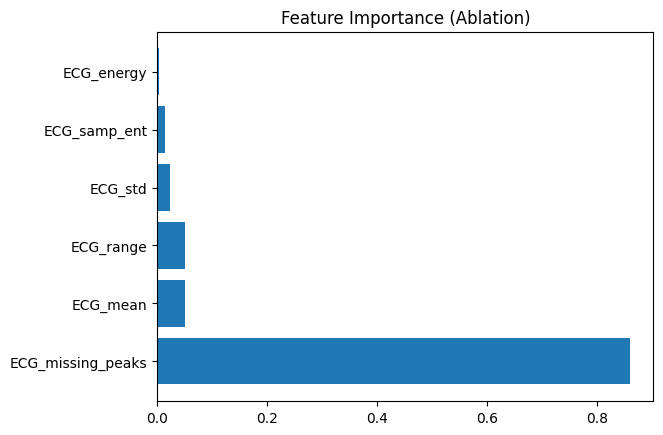

ECG_mean: 0.0511
ECG_std: 0.0229
ECG_range: 0.0504
ECG_energy: 0.0027
ECG_samp_ent: 0.0132
ECG_missing_peaks: 0.8597


In [18]:
# Importancia de Características (Ablation)
# Mostrar la importancia de cada característica en el modelo XGBoost (Experimento 2)
importances2 = model2.feature_importances_
feature_names2 = X_train_new.columns
# Sort for top 10
sorted_idx2 = np.argsort(importances2)[::-1][:10]
plt.barh(feature_names2[sorted_idx2], importances2[sorted_idx2])
plt.title("Feature Importance (Ablation)")
plt.show()

# Imprimir las importancias numéricamente
for name, imp in zip(feature_names2, importances2):
    print(f"{name}: {imp:.4f}")